# import libraries

In [225]:
import pandas as pd
import pickle
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# variables

In [226]:
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
S1_BANDS = ['VV', 'VH']

TRAIN_COUNTRIES = ['at', 'ee', 'bg']  
TEST_COUNTRIES  = ['ie', 'be', 'dk']      

# opening datasets

In [227]:
def load_raw_datasets(data_dir):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.pkl')):
        stem  = filepath.stem                      
        parts = stem.rsplit('_', 3)                

        if len(parts) != 4 or parts[3] != 'image':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        with open(filepath, 'rb') as f:
            data = pickle.load(f)

        datasets[f"{crop}_{country}_{year}"] = data
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(data)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [228]:
raw_data = load_raw_datasets('_data/exports/image_points_exports')

Loaded maize_corn_popcorn_at_2019_image.pkl → country=at | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_be_2019_image.pkl → country=be | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_bg_2019_image.pkl → country=bg | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_dk_2019_image.pkl → country=dk | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ee_2019_image.pkl → country=ee | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ie_2019_image.pkl → country=ie | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded potatoes_at_2019_image.pkl → country=at | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_be_2019_image.pkl → country=be | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_bg_2019_image.pkl → country=bg | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_dk_2019_image.pkl → country=dk | crop=potatoes | year=2019 | 50

In [229]:
raw_data.keys()

dict_keys(['maize_corn_popcorn_at_2019', 'maize_corn_popcorn_be_2019', 'maize_corn_popcorn_bg_2019', 'maize_corn_popcorn_dk_2019', 'maize_corn_popcorn_ee_2019', 'maize_corn_popcorn_ie_2019', 'potatoes_at_2019', 'potatoes_be_2019', 'potatoes_bg_2019', 'potatoes_dk_2019', 'potatoes_ee_2019', 'potatoes_ie_2019', 'winter_barley_at_2019', 'winter_barley_be_2019', 'winter_barley_bg_2019', 'winter_barley_dk_2019', 'winter_barley_ee_2019', 'winter_barley_ie_2019'])

In [230]:
def load_embedding_datasets(data_dir):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.parquet')):
        stem  = filepath.stem                      
        parts = stem.rsplit('_', 3)                

        if len(parts) != 4 or parts[3] != 'embedding':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        df = pd.read_parquet(filepath)
        df['crop']    = crop
        df['country'] = country
        df['year']    = year

        datasets[f"{crop}_{country}_{year}"] = df
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(df)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [231]:
embedding_data = load_embedding_datasets('_data/exports/embeddings_exports')

Loaded maize_corn_popcorn_at_2019_embedding.parquet → country=at | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_be_2019_embedding.parquet → country=be | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_bg_2019_embedding.parquet → country=bg | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_dk_2019_embedding.parquet → country=dk | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ee_2019_embedding.parquet → country=ee | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_ie_2019_embedding.parquet → country=ie | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_pt_2019_embedding.parquet → country=pt | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded potatoes_at_2019_embedding.parquet → country=at | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_be_2019_embedding.parquet → country=be | crop=potatoes | year=2019 |

In [232]:
embedding_data.keys()

dict_keys(['maize_corn_popcorn_at_2019', 'maize_corn_popcorn_be_2019', 'maize_corn_popcorn_bg_2019', 'maize_corn_popcorn_dk_2019', 'maize_corn_popcorn_ee_2019', 'maize_corn_popcorn_ie_2019', 'maize_corn_popcorn_pt_2019', 'potatoes_at_2019', 'potatoes_be_2019', 'potatoes_bg_2019', 'potatoes_dk_2019', 'potatoes_ee_2019', 'potatoes_ie_2019', 'potatoes_pt_2019', 'winter_barley_at_2019', 'winter_barley_be_2019', 'winter_barley_bg_2019', 'winter_barley_dk_2019', 'winter_barley_ee_2019', 'winter_barley_ie_2019'])

In [233]:
embedding_data['maize_corn_popcorn_at_2019'].head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,15.95,48.65,628,638,EPSG:32633,"[3.0008357, 1.5298377, 4.059954, 7.472669, 3.2...","[15.985727711616656, 48.64358116680461]",maize_corn_popcorn,at,2019,at
1,16.55,47.95,240,355,EPSG:32633,"[4.665599, 1.133074, 2.932662, 4.7989016, 3.33...","[16.546969834985113, 47.979056503789096]",maize_corn_popcorn,at,2019,at
2,13.95,48.25,37,126,EPSG:32633,"[3.1382673, -0.12553069, 2.510614, 3.263798, 1...","[13.915045903720529, 48.296755844896495]",maize_corn_popcorn,at,2019,at


# classifiers

In [234]:
models = {'LogisticRegression': Pipeline([('scaler', StandardScaler()), 
                                          ('clf', LogisticRegression(max_iter=1000, random_state=42))]), 
          'RandomForest': Pipeline([('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])}


def evaluate_model(name, pipeline, x_train, y_train, x_test, y_test):
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    print(f"--{name}--")
    print(classification_report(y_test, y_pred))

    accuracy = accuracy_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return pipeline, accuracy 

# raw data

## compute indices

In [235]:
def compute_s1_indices(s1):
    s1  = s1.copy()
    eps = 1e-8
    s1['VV_VH_ratio'] = s1['VV'] / (s1['VH'] + eps)
    s1['RVI']         = 4 * s1['VH'] / (s1['VV'] + s1['VH'] + eps)
    return s1

In [236]:
def compute_s2_indices(s2):
    s2  = s2.copy()
    eps = 1e-8
    s2['NDVI'] = (s2['B8']  - s2['B4']) / (s2['B8']  + s2['B4'] + eps)
    s2['NDWI'] = (s2['B3']  - s2['B8']) / (s2['B3']  + s2['B8'] + eps)
    s2['NDRE'] = (s2['B8']  - s2['B5']) / (s2['B8']  + s2['B5'] + eps)
    s2['EVI']  = 2.5 * (s2['B8'] - s2['B4']) / (s2['B8'] + 6*s2['B4'] - 7.5*s2['B2'] + 1 + eps)
    return s2

In [237]:
raw_data['potatoes_at_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date
0,16.083572,48.393816,-4.416768,-15.207887,2019-01-02 05:09:54
1,16.083572,48.393816,-4.596389,-13.355788,2019-01-02 05:09:56


In [238]:
raw_data['potatoes_at_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date
0,16.083572,48.393816,8808,8528,8440,9478,9163,9072,8800,8963,4132,3890,2019-01-01 10:07:13
1,16.083572,48.393816,5772,5160,4940,5017,4869,4788,5116,4691,3009,2647,2019-01-03 09:57:19


In [239]:
for key in raw_data.keys():
    crop_country_year = raw_data[key]
    for i in range(len(crop_country_year)):
        s1 = crop_country_year[i]['s1']
        s2 = crop_country_year[i]['s2']
        raw_data[key][i]['s1'] = compute_s1_indices(s1)
        raw_data[key][i]['s2'] = compute_s2_indices(s2)

In [240]:
raw_data['potatoes_at_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date,VV_VH_ratio,RVI
0,16.083572,48.393816,-4.416768,-15.207887,2019-01-02 05:09:54,0.290426,3.099751
1,16.083572,48.393816,-4.596389,-13.355788,2019-01-02 05:09:56,0.344150,2.975859


In [241]:
raw_data['potatoes_at_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date,NDVI,NDWI,NDRE,EVI
0,16.083572,48.393816,8808,8528,8440,9478,9163,9072,8800,8963,4132,3890,2019-01-01 10:07:13,0.020882,-0.015697,-0.037094,-0.135972
1,16.083572,48.393816,5772,5160,4940,5017,4869,4788,5116,4691,3009,2647,2019-01-03 09:57:19,0.017502,0.004282,0.009770,-0.051565


## agregate data and feature engineering on data

In [242]:
def aggregate_monthly_s1(df):
    feat_df = df[['VV', 'VH', 'VV_VH_ratio', 'RVI']].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [243]:
def aggregate_monthly_s2(df):
    s2_bands   = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
    s2_indices = ['NDVI','NDWI','NDRE','EVI']
    
    feat_df = df[s2_bands + s2_indices].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [244]:
def fit_harmonics(df, feature):
    doy = pd.to_datetime(df['date']).dt.dayofyear.values
    values = df[feature].values
    
    t = 2 * np.pi * doy / 365
    X = np.column_stack([
        np.ones_like(t),
        np.cos(t), np.sin(t),      # annual cycle
        np.cos(2*t), np.sin(2*t)   # semi annual cycle
    ])
    
    coeffs, _, _, _ = np.linalg.lstsq(X, values, rcond=None)
    
    offset      = coeffs[0]
    amplitude_1 = np.sqrt(coeffs[1]**2 + coeffs[2]**2)
    phase_1     = np.arctan2(coeffs[2], coeffs[1])
    amplitude_2 = np.sqrt(coeffs[3]**2 + coeffs[4]**2)
    phase_2     = np.arctan2(coeffs[4], coeffs[3])
    
    return offset, amplitude_1, phase_1, amplitude_2, phase_2

In [245]:
def extract_harmonic_features(s1_df, s2_df):
    features = {}
    
    for feat in ['NDVI', 'EVI', 'NDRE', 'NDWI']:
        o, a1, p1, a2, p2 = fit_harmonics(s2_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    for feat in ['VV', 'VH', 'RVI']:
        o, a1, p1, a2, p2 = fit_harmonics(s1_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    return pd.Series(features)

In [246]:
# rows = []

# for key, points_list in raw_data.items():
#     parts = key.split("_")
#     label = "_".join(parts[:-2])
#     country = parts[-2]
    
#     for point in points_list:
#         row_s1 = aggregate_monthly_s1(point['s1'])
#         row_s2 = aggregate_monthly_s2(point['s2'])
#         harmonic_row = extract_harmonic_features(point['s1'], point['s2'])
        
#         lat = point['point_coord'][1]
#         lon = point['point_coord'][0]
        
#         combined_row = pd.concat([row_s1, row_s2, harmonic_row])
#         combined_row['latitude']  = lat
#         combined_row['longitude'] = lon
#         combined_row['country'] = country
#         combined_row['crop'] = label
        
#         rows.append(combined_row)

# raw_df = pd.DataFrame(rows).reset_index(drop=True)

In [247]:
rows = []

for key, points_list in raw_data.items():
    parts = key.split("_")
    label = "_".join(parts[:-2])
    country = parts[-2]
    
    for point in points_list:
        row_s1 = aggregate_monthly_s1(point['s1'])
        row_s2 = aggregate_monthly_s2(point['s2'])
        # harmonic_row = extract_harmonic_features(point['s1'], point['s2'])
        
        lat = point['point_coord'][1]
        lon = point['point_coord'][0]
        
        # combined_row = pd.concat([row_s1, row_s2, harmonic_row])
        combined_row = pd.concat([row_s1, row_s2])
        combined_row['latitude']  = lat
        combined_row['longitude'] = lon
        combined_row['country'] = country
        combined_row['crop'] = label
        
        rows.append(combined_row)

raw_df = pd.DataFrame(rows).reset_index(drop=True)

In [248]:
print(f"Shape of raw df: {raw_df.shape}")
print(f"Crops on raw df: {raw_df['crop'].unique()}")
print(f"Countries on raw df: {raw_df['country'].unique()}")

Shape of raw df: (9000, 436)
Crops on raw df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Countries on raw df: ['at' 'be' 'bg' 'dk' 'ee' 'ie']


## split train test

In [249]:
raw_train_df = raw_df[raw_df['country'].isin(TRAIN_COUNTRIES)].reset_index(drop=True)
raw_test_df  = raw_df[raw_df['country'].isin(TEST_COUNTRIES)].reset_index(drop=True)

In [250]:
# drop columns
drop_cols = ['latitude', 'longitude', 'crop', 'country']

raw_x_train = raw_train_df.drop(columns=drop_cols)
raw_y_train = raw_train_df['crop']

raw_x_test  = raw_test_df.drop(columns=drop_cols)
raw_y_test  = raw_test_df['crop']

print(f"Train shape for raw: {raw_x_train.shape}")
print(f"Test shape for raw: {raw_x_test.shape}")

Train shape for raw: (4500, 432)
Test shape for raw: (4500, 432)


In [251]:
# check Nan values
print(f"Nan values before for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values before for raw_x_text: {raw_x_test.isnull().sum().sum()}")   

raw_x_train = raw_x_train.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean())
raw_x_test  = raw_x_test.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean()) 

print(f"Nan values after for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values after for raw_x_text: {raw_x_test.isnull().sum().sum()}")   

Nan values before for raw_x_train: 0
Nan values before for raw_x_text: 0


Nan values after for raw_x_train: 0
Nan values after for raw_x_text: 0


## apply models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.90      0.77      0.83      1500
          potatoes       0.83      0.75      0.79      1500
     winter_barley       0.80      0.98      0.88      1500

          accuracy                           0.84      4500
         macro avg       0.84      0.84      0.83      4500
      weighted avg       0.84      0.84      0.83      4500



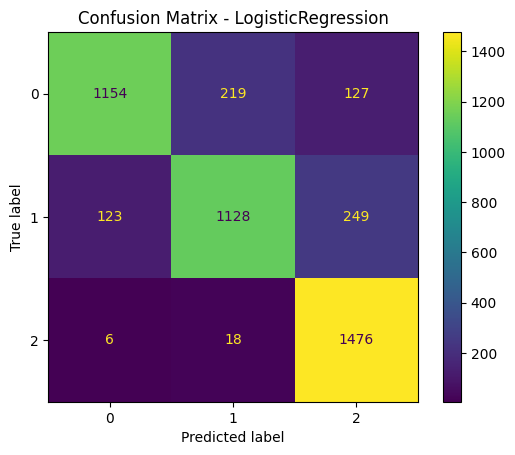

In [252]:
# logistic regression
lr_raw, lr_raw_accuracy = evaluate_model('LogisticRegression', 
                        models['LogisticRegression'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.88      0.74      0.80      1500
          potatoes       0.78      0.86      0.82      1500
     winter_barley       0.92      0.98      0.95      1500

          accuracy                           0.86      4500
         macro avg       0.86      0.86      0.86      4500
      weighted avg       0.86      0.86      0.86      4500



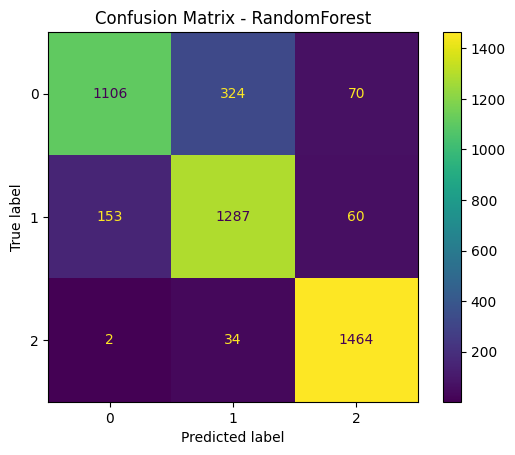

In [253]:
# random forest
rf_raw, rf_raw_accuracy = evaluate_model('RandomForest', 
                        models['RandomForest'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

# embeddings data

## pre processing

In [254]:
embeddings_df = pd.concat(embedding_data.values(), ignore_index=True)

print(f"Original embeddings shape: {embeddings_df.shape}")
print(f"Embedding length: {len(embeddings_df['embedding'].iloc[0])}")  # check embedding size

Original embeddings shape: (10000, 11)
Embedding length: 128


In [255]:
embeddings_df.head(3)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country
0,15.95,48.65,628.0,638.0,EPSG:32633,"[3.0008357, 1.5298377, 4.059954, 7.472669, 3.2...","[15.985727711616656, 48.64358116680461]",maize_corn_popcorn,at,2019,at
1,16.55,47.95,240.0,355.0,EPSG:32633,"[4.665599, 1.133074, 2.932662, 4.7989016, 3.33...","[16.546969834985113, 47.979056503789096]",maize_corn_popcorn,at,2019,at
2,13.95,48.25,37.0,126.0,EPSG:32633,"[3.1382673, -0.12553069, 2.510614, 3.263798, 1...","[13.915045903720529, 48.296755844896495]",maize_corn_popcorn,at,2019,at


In [256]:
# drop whats no necessary
embeddings_df = embeddings_df.drop(columns=['tile_lon', 'tile_lat', 'pixel_row', 'pixel_col', 'crs', 'country_id', 'year'])
embeddings_df = embeddings_df[embeddings_df['country'] != 'pt'].reset_index(drop=True)
print(f"Processed embeddings shape: {embeddings_df.shape}")

Processed embeddings shape: (9000, 4)


In [257]:
embeddings_df.head(3)

,embedding,long_lat,crop,country
0,"[3.0008357, 1.5298377, 4.059954, 7.472669, 3.2...","[15.985727711616656, 48.64358116680461]",maize_corn_popcorn,at
1,"[4.665599, 1.133074, 2.932662, 4.7989016, 3.33...","[16.546969834985113, 47.979056503789096]",maize_corn_popcorn,at
2,"[3.1382673, -0.12553069, 2.510614, 3.263798, 1...","[13.915045903720529, 48.296755844896495]",maize_corn_popcorn,at


In [258]:
# expand the embeddings to features
emb_df = pd.DataFrame(embeddings_df['embedding'].tolist(), 
                             columns=[f'emb_{i}' for i in range(len(embeddings_df['embedding'].iloc[0]))])

emb_df['latitude']  = embeddings_df['long_lat'].apply(lambda x: x[1])
emb_df['longitude'] = embeddings_df['long_lat'].apply(lambda x: x[0])
emb_df['crop']      = embeddings_df['crop']
emb_df['country']   = embeddings_df['country']

print(f"Final embeddings shape: {embeddings_df.shape}")

Final embeddings shape: (9000, 4)


In [259]:
emb_df.head(3)

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,latitude,longitude,crop,country
0,3.000836,1.529838,4.059954,7.472669,3.236195,-0.294200,-5.177912,1.765197,-0.294200,4.883713,...,0.882599,-2.471276,-5.472112,-0.941439,6.237031,0.882599,48.643581,15.985728,maize_corn_popcorn,at
1,4.665599,1.133074,2.932662,4.798902,3.332571,0.066651,-2.466102,0.866468,1.666285,3.999085,...,1.932891,-3.799130,-5.532067,-0.466560,4.199039,2.466102,47.979057,16.546970,maize_corn_popcorn,at
2,3.138267,-0.125531,2.510614,3.263798,1.820195,0.439357,-5.209524,0.062765,-0.815949,5.523350,...,0.376592,-3.765921,-6.276535,-1.443603,-0.313827,-1.506368,48.296756,13.915046,maize_corn_popcorn,at


## split train test

In [260]:
emb_train_df = emb_df[emb_df['country'].isin(TRAIN_COUNTRIES)].reset_index(drop=True)
emb_test_df  = emb_df[emb_df['country'].isin(TEST_COUNTRIES)].reset_index(drop=True)

In [261]:
drop_cols = ['latitude', 'longitude', 'crop', 'country']

emb_x_train = emb_train_df.drop(columns=drop_cols)
emb_y_train = emb_train_df['crop']

emb_x_test  = emb_test_df.drop(columns=drop_cols)
emb_y_test  = emb_test_df['crop']

print(f"Train shape for embeddigns: {emb_x_train.shape}")
print(f"Test shape for embeddings: {emb_x_test.shape}")

Train shape for embeddigns: (4500, 128)
Test shape for embeddings: (4500, 128)


In [262]:
# check Nan values
print(f"Nan values before for emb_x_train: {emb_x_train.isnull().sum().sum()}")  
print(f"Nan values before for emb_x_text: {emb_x_test.isnull().sum().sum()}")   

emb_x_train = emb_x_train.fillna(0)
emb_x_test  = emb_x_test.fillna(0)

print(f"Nan values after for emb_x_train: {emb_x_train.isnull().sum().sum()}")  
print(f"Nan values after for emb_x_text: {emb_x_test.isnull().sum().sum()}")   

Nan values before for emb_x_train: 0
Nan values before for emb_x_text: 896
Nan values after for emb_x_train: 0
Nan values after for emb_x_text: 0


In [263]:
print(f"Train shape for embeddigns: {emb_x_train.shape}")
print(f"Test shape for embeddings: {emb_x_test.shape}")

Train shape for embeddigns: (4500, 128)
Test shape for embeddings: (4500, 128)


## apply models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.96      0.78      0.86      1500
          potatoes       0.83      0.92      0.87      1500
     winter_barley       0.90      0.96      0.93      1500

          accuracy                           0.89      4500
         macro avg       0.90      0.89      0.89      4500
      weighted avg       0.90      0.89      0.89      4500



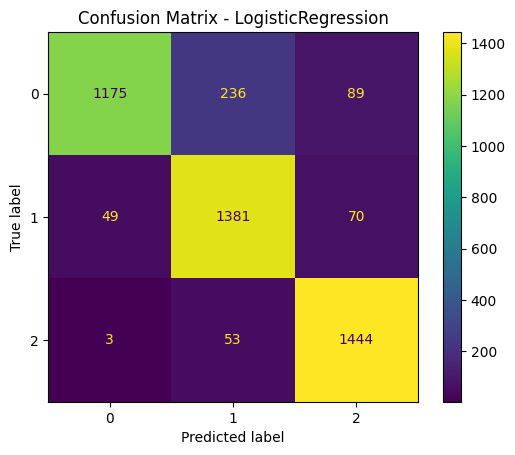

In [264]:
# logistic regression
lr_emb, lr_emb_accuracy = evaluate_model('LogisticRegression', 
                        models['LogisticRegression'], 
                        emb_x_train, emb_y_train, emb_x_test, emb_y_test)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.98      0.82      0.90      1500
          potatoes       0.85      0.93      0.88      1500
     winter_barley       0.91      0.97      0.94      1500

          accuracy                           0.91      4500
         macro avg       0.91      0.91      0.91      4500
      weighted avg       0.91      0.91      0.91      4500



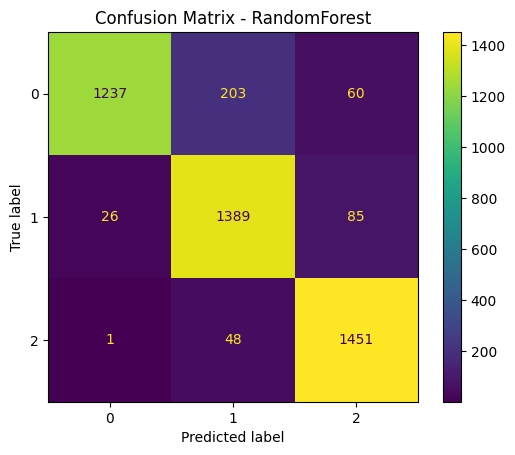

In [265]:
# random forest
rf_raw, rf_raw_accuracy = evaluate_model('RandomForest', 
                        models['RandomForest'], 
                        emb_x_train, emb_y_train, emb_x_test, emb_y_test)